# Домашнее задание по Random Forest

## Импорт базовых библиотек и загрузка датасета

В данном домашнем задании я исследую решающее дерево  и случайный лес. Это домашнее основанно на домашних задания 2(где надо было предобработать) и 4(линейной регрессии). Буду сравнивать результаты, полученные в дз4, с этими моделями из задания. В домашнем задании 4 ещё я исследовала разную предобработку данных. Для краткости, я приведу тут последнюю удачную предобработку (подстроенную под случайный лес конечно).

Ниже показаны результаты обучения линейной регрессии

<img src="image-20260425-192709.png" width="" align="" />

<img src="image-20260425-192918.png" width="" align="" />

Данный датасет представляет собой данные с сайта Airbnb. Этот сайт предоставляет квартиры для краткосрочной аренды. В нашем случае квартиры находятся в NYC. Наш таргет будет цена квартиры (задача регрессии)

Импортируем базовые библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df = pd.read_csv('/work/AB_NYC_2019.csv')
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## EDA

Для начала быстро осмотрим датасет с помощью базовых команд и просто взглянув на строки датасета.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [16]:
print(f"Всего дубликатов - {df.duplicated().astype('int').sum()}")

Всего дубликатов - 0


Первичный осмотр дал следующее:
- Всего 48895 строк
- Всего у нас 16 колонок, есть числовые и категориальные признаки
- id, name, host_id, host_name можно отсеять, хотя из последних двух признаков можно постараться сделать некий информативный признак (пол или количество комнат у хозяина, но посмотримм)
- В колонках host_name, name, last_review, reviews_per_month есть явные пропуски
- Всего дублирующих строк = 0

Хочу посмотреть на базовые статистики в датасете

In [44]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Посмотрим, все ли уникальны значения в колонке id

In [24]:
n_unique_id = len(df['id'].unique())
print(f"Число уникальных id = {n_unique_id}")

Число уникальных id = 48895


Круто, id все уникальные

In [12]:
mismatches = (
    df.groupby("host_id")["id"].transform("count")
    .ne(df["calculated_host_listings_count"])
    .sum()
)
print(f"Всего несовпадений с количеством квартир у хозяина с calculated_host_listings_count = {mismatches}")

Всего несовпадений с количеством квартир у хозяина с calculated_host_listings_count = 0


Супер, я думала создавать отдельный признак, где будет отражаться количество квартир у хозяина, но система за меня все сделала, значит **удаляем host_id**

Изучим с чем связаны пропуски в name

In [2]:
print("Распределение разных числовых признаков, где name пропущено")
df[df['name'].isnull()].describe()

Распределение разных числовых признаков, где name пропущено


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,1.600000e+01,1.600000e+01,16.000000,16.000000,16.000000,16.000000,16.000000,6.000000,16.000000,16.000000
mean,8.410815e+06,3.672124e+07,40.742235,-73.956065,147.625000,64.875000,2.687500,0.153333,1.312500,89.375000
std,5.385275e+06,2.423883e+07,0.057460,0.035822,102.037166,249.373582,6.973462,0.172124,1.014479,159.955775
min,1.615764e+06,1.832442e+06,40.664090,-74.016200,40.000000,1.000000,0.000000,0.020000,1.000000,0.000000
25%,4.528898e+06,2.137588e+07,40.709407,-73.989267,69.250000,1.000000,0.000000,0.032500,1.000000,0.000000
50%,8.054179e+06,3.226261e+07,40.718390,-73.947835,120.000000,2.000000,0.000000,0.080000,1.000000,0.000000
75%,1.073864e+07,4.985894e+07,40.772878,-73.930373,203.750000,4.000000,1.500000,0.225000,1.000000,85.250000
max,2.227582e+07,8.528834e+07,40.860320,-73.884930,400.000000,1000.000000,28.000000,0.450000,5.000000,365.000000


Можно заметить следующее:
- Этих строк ничтожно мало по сравнению с общим количеством строк (16 против 48895)
- Большинство объявлений - новые (нет отзывов вовсе)
- 50 процентов показывают availablity_365 = 0
- Тут есть явный выброс в minimum_nights = 1000
Решение: Пока оставлю, явных паттернов пока что нету

In [16]:
print("Распределение разных числовых признаков, где host_name пропущено")
df[df['host_name'].isnull()].describe()

Распределение разных числовых признаков, где host_name пропущено


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.100000e+01,2.100000e+01,21.000000,21.000000,21.000000,21.000000,21.000000,16.000000,21.000000,21.000000
mean,1.265783e+07,6.399307e+07,40.736755,-73.947637,110.952381,3.714286,42.142857,1.811875,1.380952,83.857143
std,8.965730e+06,7.246035e+07,0.058753,0.048446,72.439959,6.466397,55.419568,2.079626,0.740013,137.209798
min,1.001840e+05,4.152900e+05,40.643450,-73.998010,28.000000,1.000000,0.000000,0.020000,1.000000,0.000000
25%,6.292866e+06,7.779204e+06,40.701460,-73.968360,55.000000,1.000000,1.000000,0.110000,1.000000,0.000000
50%,1.070985e+07,3.272206e+07,40.739490,-73.953550,100.000000,1.000000,6.000000,0.845000,1.000000,0.000000
75%,2.186771e+07,1.196093e+08,40.775870,-73.936430,139.000000,4.000000,81.000000,3.282500,1.000000,88.000000
max,3.046834e+07,2.287500e+08,40.838440,-73.761330,325.000000,30.000000,182.000000,5.970000,3.000000,359.000000


Сравнивая с статистиками всего датасета, например по number_of_reviews. Во всем датасете среднее около 42 что почти совпадает с датасетом, где host_name пропущено. И медианы почти равны. Значит, это не фейки, не боты, а нормальные люди. Значит оставляем однозначно

Проверяем с чем связаны пропуски в last_reviews и в reviews_per_month

In [26]:
null_last_review = df['last_review'].isna().astype('int').sum()
null_reviews_per_month = df['reviews_per_month'].isna().astype('int').sum()
only_one_null_in_pair = (df['last_review'].isna() != df['reviews_per_month'].isna()).astype('int').sum()
print(f"Количество строк, где last_reviews null = {null_last_review}")
print(f"Количество строк, где reviews_per_month null = {null_reviews_per_month}")
print(f"Количество строк, где из этой парочки только один null = {only_one_null_in_pair }")

Количество строк, где last_reviews null = 10052
Количество строк, где reviews_per_month null = 10052
Количество строк, где из этой парочки только один null = 0


In [28]:
n1 = df[df['number_of_reviews'] == 0]['last_review'].isna().astype('int').sum()
# .count() считает строки, игнорируя Nan
n2 = df[df['number_of_reviews'] == 0]['last_review'].count()

print(f"Количество строк, где reviews = 0 и last_review null = {n1}")
print(f"Количество строк, где reviews = 0 и last_review not null = {n2}")

Количество строк, где reviews = 0 и last_review null = 10052
Количество строк, где reviews = 0 и last_review not null = 0


Из этого можно сделать вывод, что пропуски в last_review и reviews_per_month имеют конкретное значение: number_of_reviews = 0 что значит, что отзывов не было вовсе

Изучу диапазон даты последнего отзыва

In [36]:
n_empty_datetime = df["last_review"].isna().sum()
#to_datetime приводит в Null и неправильно написанную дату и пустую
n_incorrect_datetime = pd.to_datetime(df['last_review'], errors='coerce').isna().sum() - n_empty_datetime
print(f"Неправильно написанных дат всего {n_incorrect_datetime}")

Неправильно написанных дат всего 0


In [2]:
date_of_last_review = pd.to_datetime(df['last_review'])
first_date = date_of_last_review.min()
last_date = date_of_last_review.max()
print(f"Даты лежат в диапазоне {first_date} - {last_date}")

Даты лежат в диапазоне 2011-03-28 00:00:00 - 2019-07-08 00:00:00


Отлично, все даты корректные. Исходя из данного диапазона обозначим дату последнего отзыва для пустых значений равным например 2009-01-01

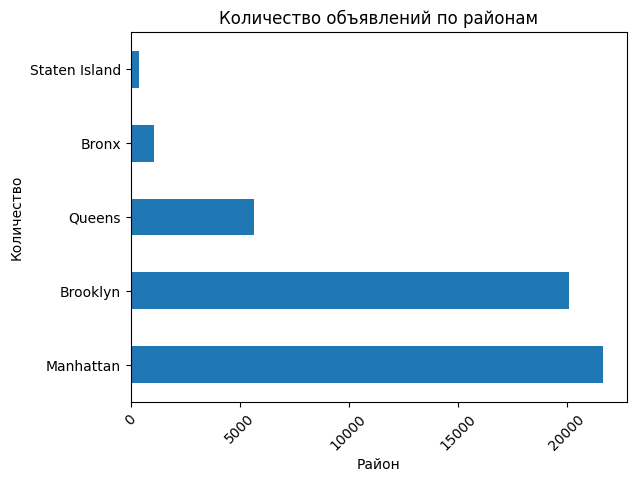

In [10]:
df['neighbourhood_group'].value_counts().plot.barh()
plt.title("Количество объявлений по районам")
plt.xlabel("Район")
plt.ylabel("Количество")
plt.xticks(rotation=45)

plt.show()

Интересно, есть дисбаланс по количествам объявлениям в районах

In [10]:
print('Средняя цена для каждого района:')
df.groupby('neighbourhood_group')['price'].mean()

Средняя цена для каждого района:


neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

In [14]:
print(' для каждого района:')
df.groupby('neighbourhood_group')['price'].median()

Медиана для каждого района:


neighbourhood_group
Bronx             65.0
Brooklyn          90.0
Manhattan        150.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64

Интересная ситуация у Staten island. В среднем он показал себя неплохо, когда как в медиане он среднячок. Это говорит, что у нас скошенное распределение. Среднее вытянули выбросы и маленькое количество объявлений вовсе. Но тем не менее Манхеттен самый дорогой район, что ожидаемо.

In [12]:
n_kvartals = len(df['neighbourhood'].unique())
print(f'Всего кварталов - {n_kvartals}')

Всего кварталов - 221


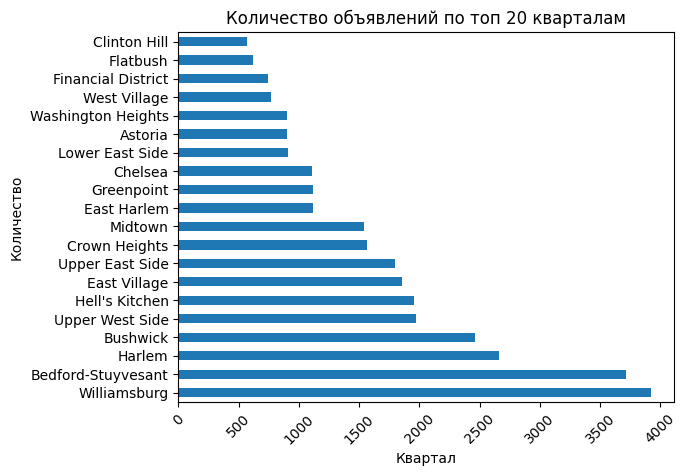

In [18]:
df['neighbourhood'].value_counts().head(20).plot.barh()
plt.title("Количество объявлений по топ 20 кварталам")
plt.xlabel("Квартал")
plt.ylabel("Количество")
plt.xticks(rotation=45)

plt.show()

Кварталов очень много! Плюс также есть дисбалансы между количеством объявлений

In [8]:
df.groupby('neighbourhood').size().sort_values().head(10)

neighbourhood
Rossville         1
Richmondtown      1
Fort Wadsworth    1
Willowbrook       1
New Dorp          1
Woodrow           1
Co-op City        2
West Farms        2
Howland Hook      2
Westerleigh       2
dtype: int64

Рассмотрим room_type

In [2]:
n_room_type = len(df['room_type'].unique())
print(f'Всего типов комнат - {n_room_type}')

Всего типов комнат - 3


In [4]:
df['room_type'].value_counts(normalize=True)

room_type
Entire home/apt    0.519665
Private room       0.456611
Shared room        0.023724
Name: proportion, dtype: float64

In [6]:
print('Средняя цена для каждого типа комнат:')
df.groupby('room_type')['price'].mean()

Средняя цена для каждого типа комнат:


room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          53.5         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0



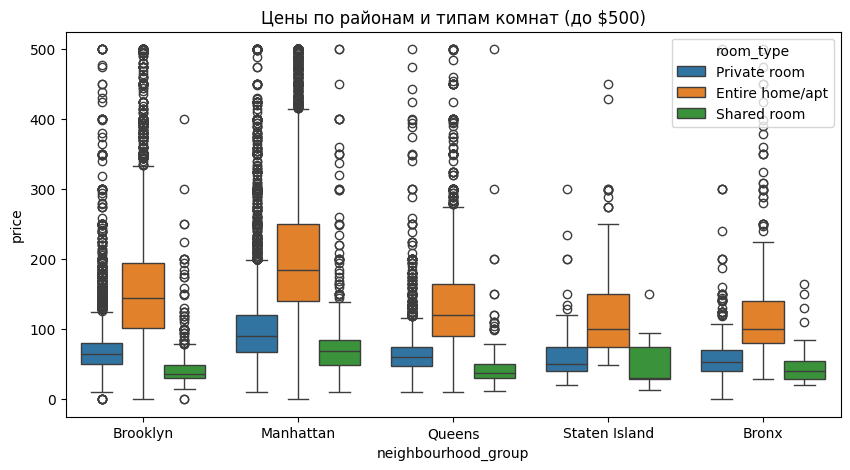

In [4]:
cross = df.groupby(['neighbourhood_group', 'room_type'])['price'].median().unstack()
print(cross)
print()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[df['price'] <= 500], x='neighbourhood_group', y='price', hue='room_type', ax=ax)
ax.set_title('Цены по районам и типам комнат (до $500)')
plt.show()

Снова видим картину, что Манхеттен самый дорогой, а Entire home/apt самый дорогой слот для всех районов. 

Теперь рассмотрим price

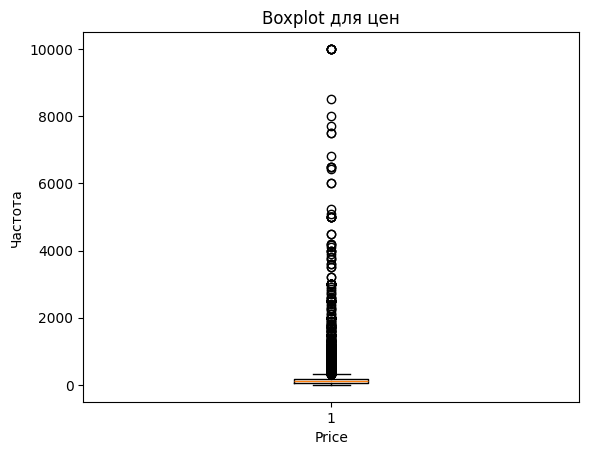

In [4]:
plt.boxplot(df['price'])
plt.title('Boxplot для цен')
plt.xlabel('Price')
plt.ylabel('Частота')
plt.show()

In [32]:
print('Характеристики для цены equal or less than 1000:')

var = df['price'].clip(upper=1000).var()
std = df['price'].clip(upper=1000).std()
skew = df['price'].clip(upper=1000).skew()
kurtosis = df['price'].clip(upper=1000).kurtosis()

print(f'Дисперсия = {var}')
print(f'Стандартное отклонение - {std}')
print(f'Skewness = {skew}')
print(f'Эксцесс = {kurtosis}')

Характеристики для цены equal or less than 1000:
Дисперсия = 17147.90903849956
Стандартное отклонение - 130.95002496563168
Skewness = 3.3570187271944323
Эксцесс = 15.622189267479413


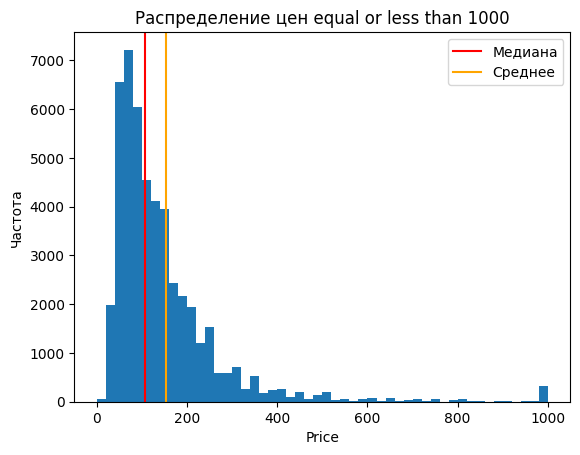

In [34]:
plt.hist(df['price'].clip(upper=1000), bins=50)
plt.axvline(df['price'].median(), color='red', label='Медиана')
plt.axvline(df['price'].mean(), color='orange', label='Среднее')

plt.legend()
plt.title('Распределение цен equal or less than 1000')
plt.xlabel('Price')
plt.ylabel('Частота')
plt.show()

Распределение цен скошено вправо. А это еще не считали выбросы, которые очень сильные. Причем по boxplot можно сказать, что их и не мало. Лучше всего мега выбросы стоит выбросить, потому что смогут тянуть на себя ошибки. Возможно придется логарифмировать.

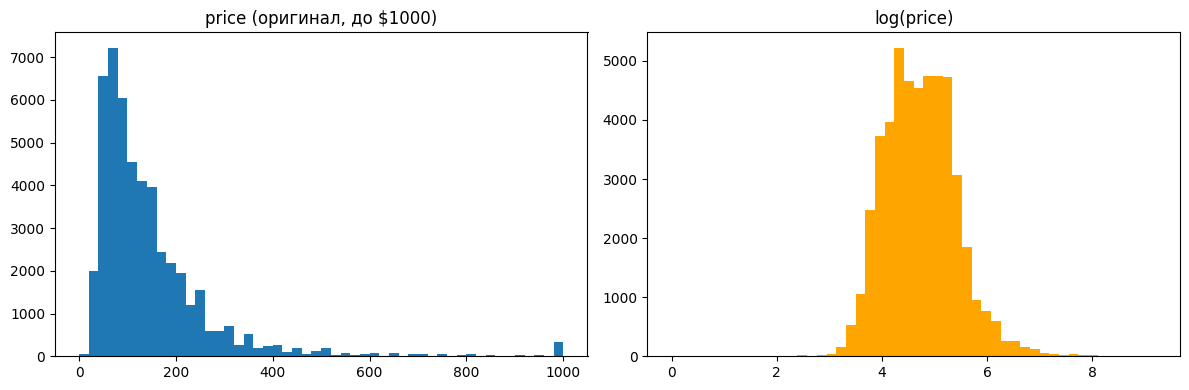

Skewness оригинала: 19.12
Skewness после лога: 0.55


In [6]:
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'].clip(upper=1000), bins=50)
axes[0].set_title('price (оригинал, до $1000)')

axes[1].hist(df['log_price'], bins=50, color='orange')
axes[1].set_title('log(price)')

plt.tight_layout()
plt.show()

print(f"Skewness оригинала: {df['price'].skew():.2f}")
print(f"Skewness после лога: {df['log_price'].skew():.2f}")

Логарифмирование лучше нормализовала price

Посмотрим на парные зависимости цены от числовых признаков

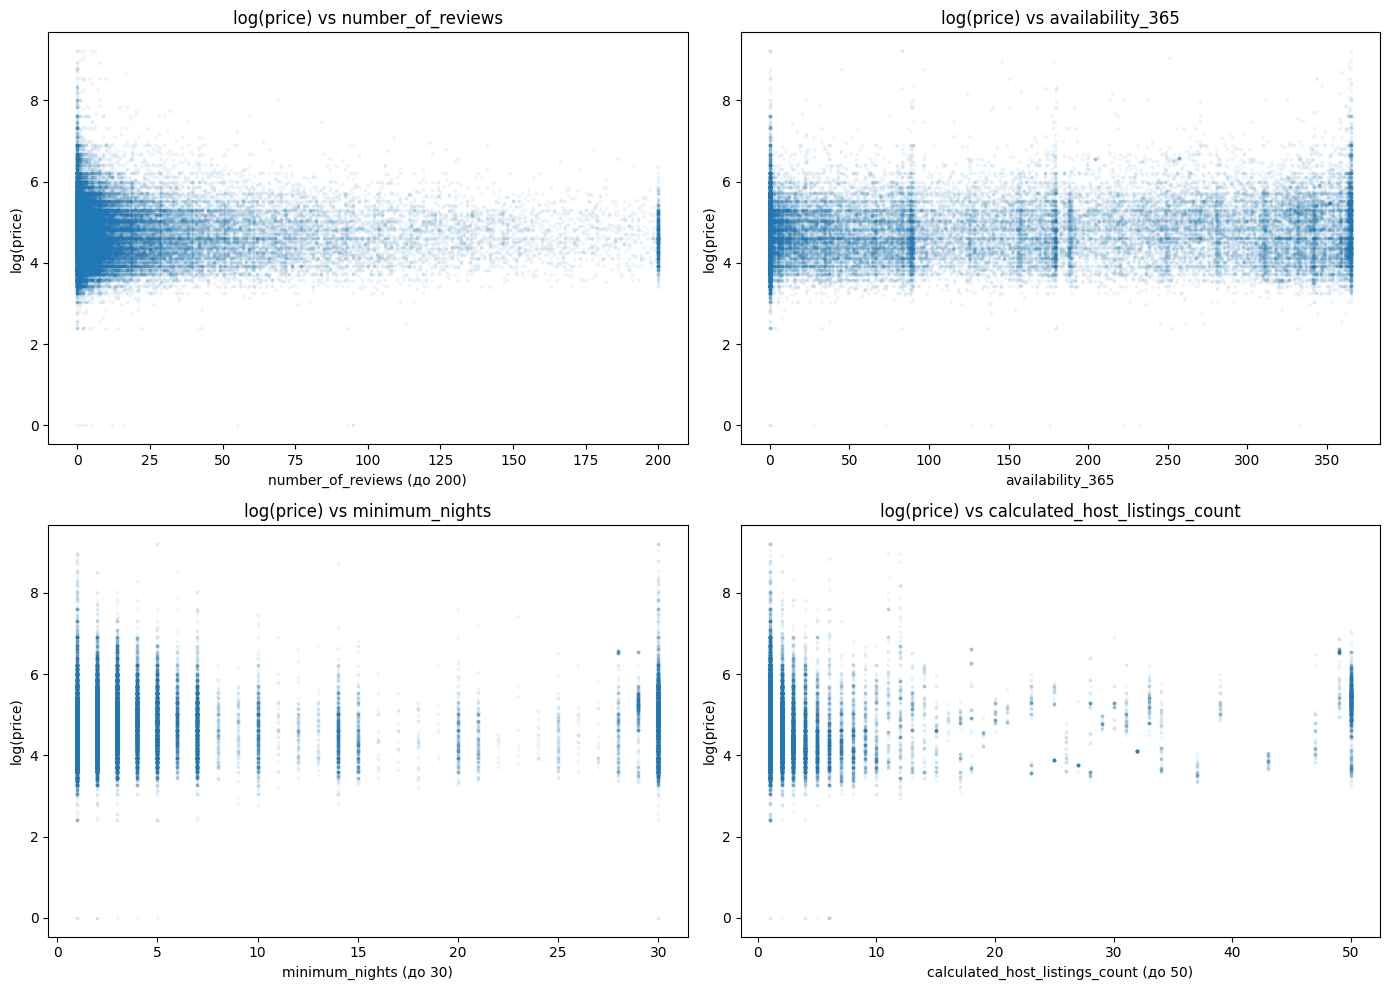

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# log_price vs number_of_reviews
axes[0, 0].scatter(df['number_of_reviews'].clip(upper=200), df['log_price'], alpha=0.05, s=3)
axes[0, 0].set_xlabel('number_of_reviews (до 200)')
axes[0, 0].set_ylabel('log(price)')
axes[0, 0].set_title('log(price) vs number_of_reviews')

# log_price vs availability_365
axes[0, 1].scatter(df['availability_365'], df['log_price'], alpha=0.05, s=3)
axes[0, 1].set_xlabel('availability_365')
axes[0, 1].set_ylabel('log(price)')
axes[0, 1].set_title('log(price) vs availability_365')

# log_price vs minimum_nights
axes[1, 0].scatter(df['minimum_nights'].clip(upper=30), df['log_price'], alpha=0.05, s=3)
axes[1, 0].set_xlabel('minimum_nights (до 30)')
axes[1, 0].set_ylabel('log(price)')
axes[1, 0].set_title('log(price) vs minimum_nights')

# log_price vs calculated_host_listings_count
axes[1, 1].scatter(df['calculated_host_listings_count'].clip(upper=50), df['log_price'], alpha=0.05, s=3)
axes[1, 1].set_xlabel('calculated_host_listings_count (до 50)')
axes[1, 1].set_ylabel('log(price)')
axes[1, 1].set_title('log(price) vs calculated_host_listings_count')

plt.tight_layout()
plt.show()

Что можно сказать. Во-первых, где отзывы около нуля там наблюдается такой треугольник цен. Чем больше отзывов, тем уже (хоть уже в перспективе диапазон почти один и тот же и не наблюдается какой-то связи). Дорогие объявления менее популярны. Еще большой диапазон у крайних значений availability_365. Линейной связи тоже не наблюдаю. Аналоигчно с остальными. Хотя по количеству у хозяина наблюдается некая тенденция. Чем больше квартир у хозяина, тем больше цены сконцетрированны на одной высоте (а значит в неком узком диапазоне). У тех, у кого 1- 2 квартиры не такая ситуация, они больше разбросаны.

In [18]:
!pip install phik==0.12.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 8.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


interval columns not set, guessing: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
/root/venv/lib/python3.11/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable last_review is large: 1764. Are you sure this is not an interval variable? Analysis for pairs of variables including last_review can be slow.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

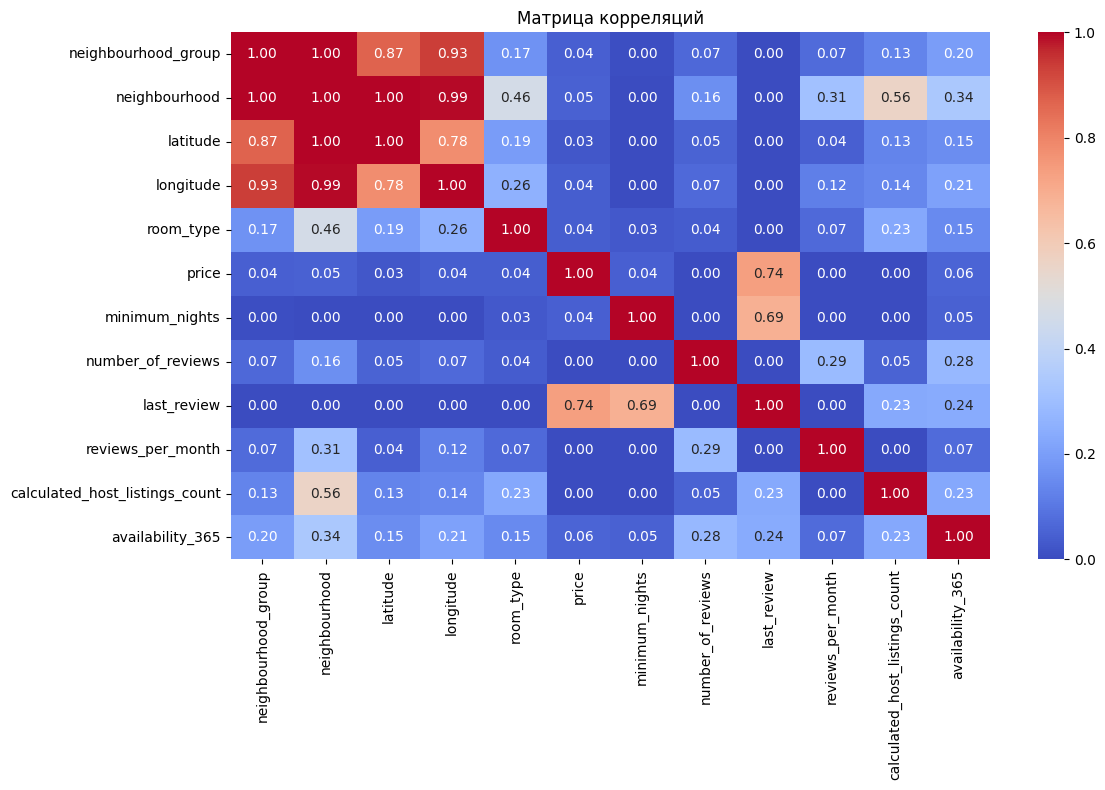

In [22]:
import phik
from phik.report import plot_correlation_matrix

corr_matrix = df.drop(columns=['id', 'host_id', 'name', 'host_name']).phik_matrix()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show

Посмотрим на зависимость log(price) от некоторых числовых характеристик

Посмотрим на аномальные на наш взгляд значения

In [10]:
checks = {
    'price == 0':               (df['price'] == 0).sum(),
    'price > 1000':             (df['price'] > 1000).sum(),
    'minimum_nights > 365':     (df['minimum_nights'] > 365).sum(),
    'minimum_nights > 30':      (df['minimum_nights'] > 30).sum(),
    'availability_365 == 0':    (df['availability_365'] == 0).sum(),
    'availability_365 == 365':  (df['availability_365'] == 365).sum(),
    'number_of_reviews == 0':   (df['number_of_reviews'] == 0).sum(),
    'number_of_reviews > 100':  (df['number_of_reviews'] > 100).sum(),
}
for k, v in checks.items():
    print(f"{k:<35} {v:>6} ({v/len(df)*100:.2f}%)")

price == 0                              11 (0.02%)
price > 1000                           239 (0.49%)
minimum_nights > 365                    14 (0.03%)
minimum_nights > 30                    747 (1.53%)
availability_365 == 0                17533 (35.86%)
availability_365 == 365               1295 (2.65%)
number_of_reviews == 0               10052 (20.56%)
number_of_reviews > 100               2995 (6.13%)


Оп, есть price = 0. Но этого быть не может, потому что квартиры на airbnb не могут быть бесплатными. Значит эти строки(тем более их мало) удаляем. Плюс ко всему, достаточно необычно для сервиса краткосрочной аренды видеть minimum_night > 30. Лучше такие строчки удалить, чтобы наш датасет отображал типичную картину квартир краткосрочной аренды в NYC. Ещё интересно, что целых 35 процентов availability_365 = 0. Их нельзя спешить удалять. Так же и квартиры с нулем отзывов. 

Внизу показаны сколько выбросов в каждой категории. Больше всего у количества отзывов и минимального количества ночей

In [12]:
for col in ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"{col:<35} {outliers:>6} ({outliers/len(df)*100:.2f}%)")

price                                 2972 (6.08%)
minimum_nights                        6607 (13.51%)
number_of_reviews                     6021 (12.31%)
reviews_per_month                     1793 (3.67%)
availability_365                         0 (0.00%)


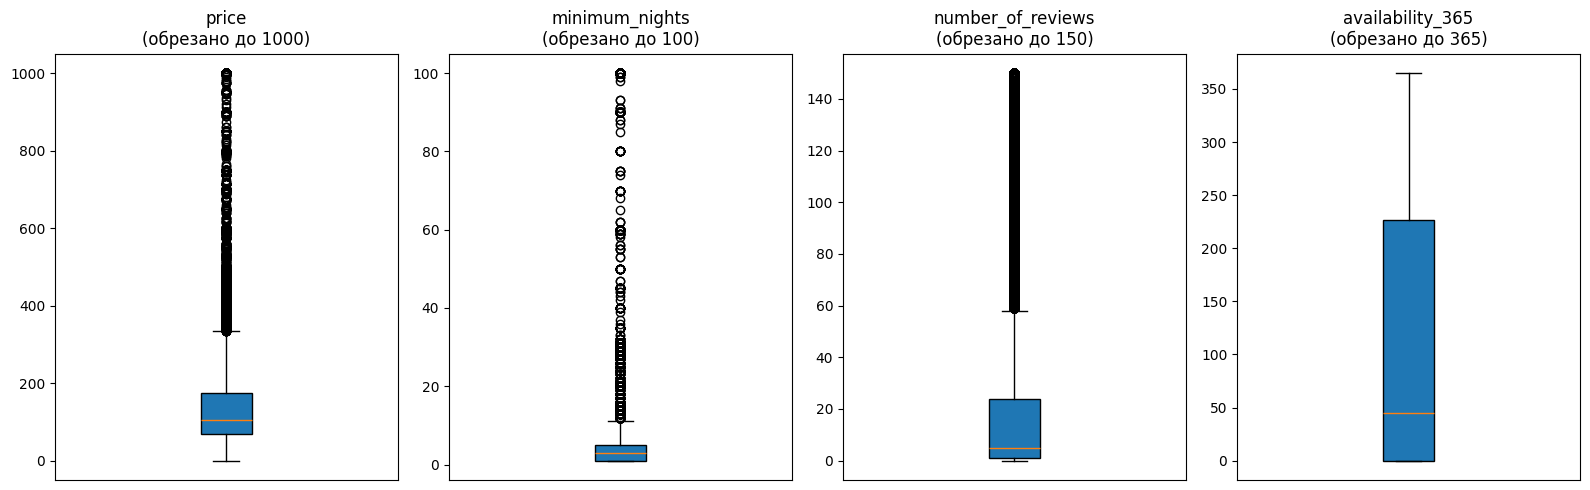

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']
clips = [1000, 100, 150, 365]

for ax, col, clip in zip(axes, cols, clips):
    ax.boxplot(df[col].clip(upper=clip), patch_artist=True)
    ax.set_title(f'{col}\n(обрезано до {clip})')
    ax.set_xticks([])

plt.tight_layout()
plt.show()

Любопытно ещё изучить объявления с availability_365 = 0

In [2]:
zero_avail = df[df['availability_365'] == 0]

popular = zero_avail[zero_avail['number_of_reviews'] >= 10]
dead = zero_avail[zero_avail['number_of_reviews'] == 0]
grey = zero_avail[(zero_avail['number_of_reviews'] > 0) & (zero_avail['number_of_reviews'] < 10)]

print(f"Всего availability_365 = 0: {len(zero_avail)}")
print(f"  Популярные (reviews >= 10): {len(popular)} ({len(popular)/len(zero_avail)*100:.1f}%)")
print(f"  Серая зона (reviews 1-9):   {len(grey)} ({len(grey)/len(zero_avail)*100:.1f}%)")
print(f"  Мёртвые (reviews = 0):      {len(dead)} ({len(dead)/len(zero_avail)*100:.1f}%)")

Всего availability_365 = 0: 17533
  Популярные (reviews >= 10): 3369 (19.2%)
  Серая зона (reviews 1-9):   9319 (53.2%)
  Мёртвые (reviews = 0):      4845 (27.6%)


Достаточно много в мертвой зоне. Если честно, даже предположить не могу, что за этим стоит (скорее всего боты). Проще удалить их из-за их сомнительности.

Визуализируем по географическим координатам цены

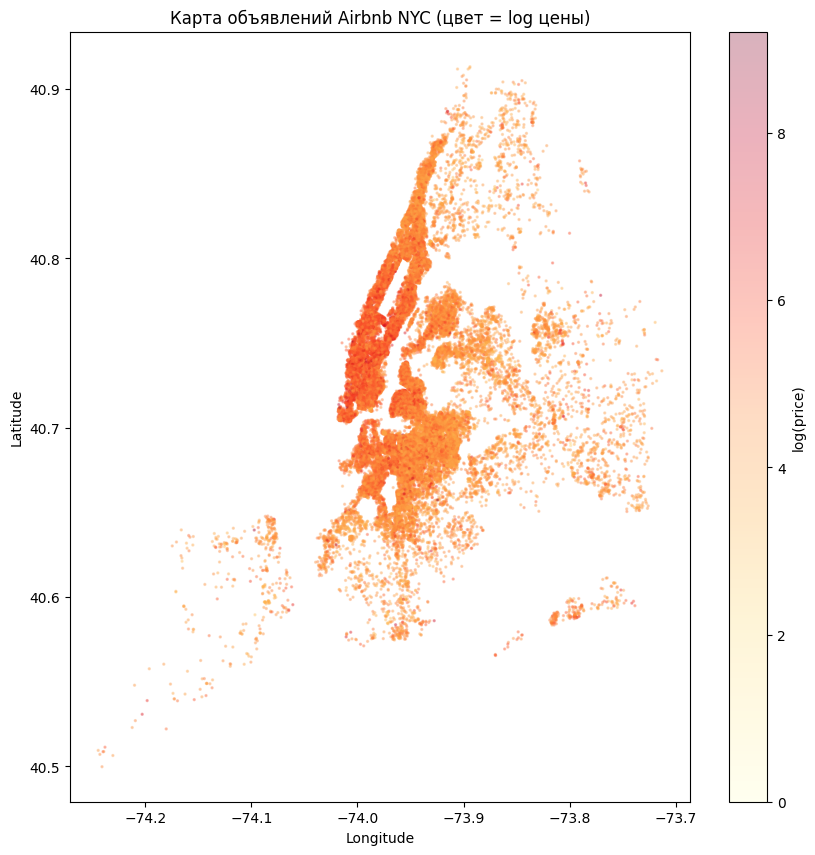

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(df['longitude'], df['latitude'],
                     c=df['log_price'], cmap='YlOrRd',
                     alpha=0.3, s=2)
plt.colorbar(scatter, label='log(price)')
ax.set_title('Карта объявлений Airbnb NYC (цвет = log цены)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

Хаха, давайте приложим карту настоящего Нью-Йорка. Хотя уже сам график отчетливо показывает очертания.

<img src="image-20260417-153553.png" width="50" align="" />

Теперь мы можем НАГЛЯДНО видеть, что Манхеттен самый дорогой. Популярные районы именно являются Бруклин и Манхеттен. А в Статен-Айленде очень мало объявлений. А ещё есть некая зависимость, что чем ближе к Тайм Сквер, тем правда дороже.

### Выводы по EDA:

- Датасет содержит 48 895 объявлений, дубликатов нет. Пропуски в last_review и reviews_per_month связаны с отсутствием отзывов (10 052 строки), пропуски в name и host_name ничтожны.
- Распределение цен сильно скошено вправо (skewness = 19.12). Логарифмирование снижает skewness до 0.55 — для линейной регрессии следует использовать log(price).
- Цена = 0 (11 строк) — ошибки данных, удаляем. Объявления с minimum_nights > 30 (747 строк) нетипичны для краткосрочной аренды — тоже удаляем. 99,5 процентов имеет цену меньше 1000. Поэтому мне легче удалить экстримальные значения
- Ключевые факторы цены — район (neighbourhood_group) и тип комнаты (room_type). Манхэттен — самый дорогой район, Entire home/apt — самый дорогой тип.
- 35.86% объявлений имеют availability_365 = 0. Из них ~19% — популярные (10+ отзывов), ~28% — мёртвые (0 отзывов), остальные — серая зона. Удалять всё нельзя, но стоит учитывать этот нюанс при моделировании. Мертвых однако стоит удалить, они слишком сомнительные
- Хозяева с большим количеством объявлений (calculated_host_listings_count) показывают более стабильные цены в среднем-верхнем диапазоне — это профессиональные арендодатели. Признак может быть полезен для модели.
- number_of_reviews отрицательно связан с ценой: дешёвые объявления бронируются чаще и получают больше отзывов.
- Географический scatter plot подтверждает зависимость цены от расположения — центр Манхэттена заметно дороже. На этапе feature engineering имеет смысл создать признак расстояния до центра.
- Корреляционная матрица (phik) показывает сильную связь между географическими признаками (neighbourhood_group, neighbourhood, latitude, longitude) и слабую связь price с большинством других переменных. Я приму решение пока что удалить neighbourhood и оставить neighbourhood_group из-за высокой вероятности переобучение (в некоторых районах правда очень мало квартир, а то и одна квартира)

## Итоговые выводы

### Что я поняла про датасет

- Датасет содержит 48 895 объявлений Airbnb в Нью-Йорке (2019). Дубликатов нет, но есть пропуски в `last_review` и `reviews_per_month` — они полностью объясняются отсутствием отзывов (number_of_reviews = 0).
- Распределение цен сильно скошено вправо (skewness = 19.12). Логарифмирование снижает skewness до 0.55 — значит, для линейной регрессии стоит использовать `log(price)` как таргет.
- Самый дорогой район — Манхэттен (медиана $150), самый дешёвый — Бронкс (медиана $65). Самый дорогой тип жилья — Entire home/apt, и это справедливо для всех районов.
- 35.86% объявлений имеют `availability_365 = 0` (из-за этого я не удалила это, хоть и выглядят такие объявления как фиктивные). Среди них ~28% — «мёртвые» (ноль отзывов + закрытый календарь), то есть неактивные объявления, которые не участвуют в реальном рынке.
- Есть 11 объявлений с price = 0 — это явные ошибки данных, им нечего делать в датасете.
- Кварталов 221, и распределение объявлений по ним крайне неравномерное: есть кварталы с одним объявлением. Это делает `neighbourhood` опасным признаком для модели — проще его убрать, чем бороться с переобучением.
- `calculated_host_listings_count` совпадает с реальным количеством объявлений у хозяина в датасете, то есть его можно использовать вместо `host_id`.
- Хозяева с большим числом объявлений (профессиональные арендодатели) ставят более стабильные цены в среднем-верхнем диапазоне.
- Расстояние до Таймс-Сквер показало самую сильную корреляцию с log(price) среди числовых признаков (−0.4). Географическая карта это подтверждает визуально.
- Числовые признаки (reviews, availability, minimum_nights) слабо коррелируют с ценой по отдельности. Основные предикторы цены — это локация и тип жилья. Сильно коррелирует last_review, но тут скорее это объясняется, что 

### Гипотезы и наблюдения

1. **Район и тип жилья — главные драйверы цены.** Комбинация `neighbourhood_group` + `room_type` объясняет большую часть вариации. Числовые признаки добавляют мало, потому что рынок аренды в первую очередь определяется расположением.
2. **Объявления с `minimum_nights > 30` — это по сути долгосрочная аренда**, другой сегмент рынка с другим ценообразованием. Их удаление делает датасет более однородным и модель — более точной для задачи краткосрочной аренды.
3. **Выбросы по цене — не ошибки, а luxury-сегмент.** Квартиры за $5000–10000 реально существуют на Airbnb, но их ценообразование работает иначе (бренд, уникальность, вид из окна). Линейная модель не сможет их предсказать, поэтому обрезка по 99-му перцентилю оправдана.
4. **Дешёвые объявления бронируются чаще** — об этом говорит облако точек «цена vs отзывы»: чем больше отзывов, тем ниже цена в среднем. Дорогие квартиры бронируют реже, отзывов у них меньше.
5. **Закрытый календарь (availability = 0) при наличии отзывов** — это скорее всего сезонные хозяева, которые сдают квартиру только в определённые месяцы и потом закрывают бронирование. Удалять их не стоит — это реальные участники рынка.

### Что бы я сделала дальше

- Обучила бы линейную регрессию на подготовленных данных и посмотрела на метрики (RMSE, MAE, R²) на тестовой выборке. Метрики надо считать на `np.expm1(log_price)`, чтобы вернуться к реальным долларам. Но мне кажется, что нелинейные модели покажут себя лучше, ведь зависимость цены от некоторых фич далеко не линейная.
- Попробовала бы Ridge или Lasso — они могут справиться лучше, если есть лишние признаки (например, `day_since_last_review` со слабой корреляцией).
- Посмотрела бы на коэффициенты модели — какие признаки оказались важными, совпадает ли это с EDA.
- Попробовала бы дерево решений или случайный лес для сравнения — им не нужна нормализация и они могут ловить нелинейные зависимости.
- Посмотрела бы residuals — где модель ошибается сильнее всего (может быть, в определённых районах или ценовых сегментах).

## Какие подсказки брала у AI и что проверяла/дописывала руками

- Спрашивала у AI, как правильно посчитать корреляцию phik и построить heatmap — адаптировала под свой датасет.
- Формулу Хаверсина для расчёта расстояния до Таймс-Сквер взяла из подсказки AI. А так идея использовать в качестве фичи расстояние сама придумала
- Идею стратифицированного split по бинам цены подсмотрела у AI — проверила руками, что пропорции действительно совпадают в train и test. Но вообще я работала с датасетами классификации, где стратификация более очевидная, поэтому задумалсь о том, почему бы также 'равномерно' разделить датасет.
- EDA, выводы, решения об удалении строк и выборе признаков — делала сама, AI использовала для проверки своих рассуждений (и мою трезвость если честно хд).
- AI помог сформулировать итоговые выводы и оформить итоговые вывод, но все наблюдения основаны на моём собственном анализе в ноутбуке.

## Предобработка данных

1. Очистка и фильтрация
- Обработка пропусков: last_review заполнен базовой датой (2006 г.), reviews_per_month — нулями.
- Удаление шума: Исключены объявления с ценой $0$, выбросы (выше 99-го перцентиля) и «мертвые» объекты без отзывов и доступности.
- Фокус сегмента: Оставлена только краткосрочная аренда (до 30 ночей).
- Дроп ID: Удалены неинформативные признаки (id, host_id, host_name).
2. Feature Engineering (Создание новых признаков)
- Гео-фактор: Рассчитано расстояние до Таймс-Сквер через формулу Хаверсина. Использован логарифм расстояния, чтобы учесть нелинейное падение цены при удалении от центра.
- Фактор свежести: Создан признак day_since_last_review — количество дней с последнего отзыва до текущего момента.
3. Работа с текстом и категориями 
- NLP (TF-IDF): Названия объявлений (name) преобразованы в 1685 признаков. Модель теперь «понимает» ценность слов типа Luxury, Cozy или Studio.
- One-Hot Encoding: Тип жилья и административный округ переведены в бинарные колонки.
- Target Encoding (сглаженное): Районы (neighbourhood) закодированы через среднюю цену.Важно: Использован K-Fold (5 фолдов) при кодировании трейна, чтобы избежать утечки целевой переменной (Data Leakage).
4. Подготовка к моделированию
- Стратифицированный сплит: Данные разделены 80/20. Разделение шло по 7 квантилям цены, что гарантирует одинаковое распределение таргета в обучении и тесте.

Подробно логика описана в дз 4

In [17]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2


df = pd.read_csv('/work/AB_NYC_2019.csv')
 
 #==заполнение пропусков и очистка==

df['last_review'] = df['last_review'].fillna('2006-01-25')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df_clean = df[
    (df['minimum_nights'] <= 30) &
    (df['price'] > 0) &
    (df['price'] < df['price'].quantile(0.99))&
    ((df['availability_365'] > 0) | (df['number_of_reviews'] > 0))
].copy()
 # Удаляем только настоящий мусор: id, host_id, host_name, name
# neighbourhood, latitude, longitude- ОСТАВЛЯЕМ
df_clean = df_clean.drop(columns=['id', 'host_id', 'host_name'])

#==Feature Engineiring
# log(price) — таргет
#df_clean['log_price'] = np.log1p(df_clean['price'])
#df_clean = df_clean.drop(columns=['price'])

#Расстояние до Таймс-Сквер (lat и lon НЕ удаляем)
TS_LAT, TS_LON = 40.7580, -73.9855
 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    #Есть теория, что зависимость цены от расстояния до центра не совсем линейная, а растет медленнее (например в окраине элитные особняки). Поэтому выбран логарифм
    return np.log(R * 2 * atan2(sqrt(a), sqrt(1 - a)))
 
df_clean['distance_to_times_sq'] = df_clean.apply(
    lambda row: haversine(row['latitude'], row['longitude'], TS_LAT, TS_LON), axis=1
)
 
# Дни с последнего отзыва
max_date = pd.to_datetime(df_clean['last_review']).max()
df_clean['day_since_last_review'] = (max_date - pd.to_datetime(df_clean['last_review'])).dt.days
df_clean = df_clean.drop(columns=['last_review'])

#==Разделение выборки на train test
seed = 45
 
X = df_clean.drop(columns=['price'])
y = df_clean['price']
 
bins = pd.qcut(y, q=7, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=bins
)

#=TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Заполняем пропуски в name
X_train['name'] = X_train['name'].fillna('')
X_test['name'] = X_test['name'].fillna('')

# fit только на трейне!
tfidf = TfidfVectorizer(max_features=1685, stop_words='english')
name_train = tfidf.fit_transform(X_train['name'])
name_test = tfidf.transform(X_test['name'])

# Превращаем в DataFrame и приклеиваем
name_train_df = pd.DataFrame(name_train.toarray(), 
                              columns=['tfidf_' + c for c in tfidf.get_feature_names_out()], 
                              index=X_train.index)
name_test_df = pd.DataFrame(name_test.toarray(), 
                              columns=['tfidf_' + c for c in tfidf.get_feature_names_out()], 
                              index=X_test.index)

X_train = X_train.drop(columns=['name']).join(name_train_df)
X_test = X_test.drop(columns=['name']).join(name_test_df)


#==One hot encoding

from sklearn.preprocessing import OneHotEncoder
 
ohe_features = ['room_type', 'neighbourhood_group']
ohe = OneHotEncoder(drop='first', sparse_output=False).set_output(transform='pandas')
ohe.fit(X_train[ohe_features])
 
train_encoded = pd.DataFrame(
    ohe.transform(X_train[ohe_features]),
    columns=ohe.get_feature_names_out(),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    ohe.transform(X_test[ohe_features]),
    columns=ohe.get_feature_names_out(),
    index=X_test.index
)
 
X_train = X_train.drop(columns=ohe_features).join(train_encoded)
X_test = X_test.drop(columns=ohe_features).join(test_encoded)

#==Target encoding
from sklearn.model_selection import KFold

def target_encode_smooth(train_values, train_target, test_values, smoothing=10):
    global_mean = train_target.mean()
 
    # --- Кодируем трейн через KFold, чтобы не было утечки ---
    encoded_train = pd.Series(0.0, index=train_values.index)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    for train_idx, val_idx in kf.split(train_values):
        #собираем фолдовский район
        fold_target = train_target.iloc[train_idx]
        fold_values = train_values.iloc[train_idx]
        
        #считаем среднюю цену на всем фолде
        fold_mean = fold_target.mean()
        
        stats = fold_target.groupby(fold_values).agg(['mean', 'count'])
        #Чем больше вес, тем больше доверия
        weight = stats['count'] / (stats['count'] + smoothing)
        #кодируем кварталы, которые встречались в 4 фолдах
        smoothed = weight * stats['mean'] + (1 - weight) * fold_mean
        #оставшийся фолд заполняем новый признак по кодам из smoothed
        encoded_train.iloc[val_idx] = train_values.iloc[val_idx].map(smoothed)
        #если квартал не встретился в 4 фолдах, то просто заполняем средним
        encoded_train.iloc[val_idx] =  encoded_train.iloc[val_idx].fillna(fold_mean)

    stats_full = train_target.groupby(train_values).agg(['mean', 'count'])
    weight_full = stats_full['count'] / (stats_full['count'] + smoothing)
    #кодируем кварталы, которые встречались в train
    smoothed_full = weight_full * stats_full['mean'] + (1 - weight_full) * global_mean
    encoded_test = test_values.map(smoothed_full)
    # Квартал не встречался в трейне - глобальное среднее
    encoded_test = encoded_test.fillna(global_mean)

    return encoded_train, encoded_test


X_train['neighbourhood_encoded'], X_test['neighbourhood_encoded'] = target_encode_smooth(
    X_train['neighbourhood'], y_train, X_test['neighbourhood'], smoothing=10
)
 
# Оригинальный neighbourhood больше не нужен
X_train = X_train.drop(columns=['neighbourhood'])
X_test = X_test.drop(columns=['neighbourhood'])

* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?**
Да, предобработка отличалась от линейной модели. Деревья не требуют масштабирования числовых признаков (так как в ноде делается разделение some_feature > some_value). Убрала полиномиальные признаки, ведь дерево уже умеет полиномиальные и сложные зависимости улавливать. И наконец, я не удаляла выбросы в ценах по 99 квантилю, как я делала это в линейной регрессии. В то время как линейная регрессия бы подстроилась под них, дерево просто для них может создать новую ноду.
* **Как именно вы разделили выборку?** 
Разделила 80/20 train и test. Также была использована стратификация. Цена разбивается на квантили, чтобы распределение таргета в train и test было одинаковым.
* **На сколько частей нужно делить выборку при использовании кросс-валидации?**
Обычно делят обучающую выборку на 5 частей (фолдов) (4 части тренируют модель, 1 часть валидационная). Иногда на 3 при больших датасетах или 10 при маленьких.
* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?** 
Можно, в таком случае исходная выборка делится на тренировочную, валидационную,тестовую. Однако в таком случае оценка качества устойчивости модели будет не такой надежной, так как сильно зависит от разделения данных. Кросс-валидация предпочтительнее.

## Обучение моделей

In [19]:
seed = 45

#### Обучение Decision Tree

Как известно из теории, для рандомного леса нужные глубокие деревья (с низким bias). Смещение ансамбль уменьшит. Так что берем любое глубоке дерево (я возьму глубины 15)

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'max_depth': [15]
}

tree = DecisionTreeRegressor(random_state=seed)
model = GridSearchCV(
    tree, 
    param_grid,
    scoring='r2',
    cv=5,
    verbose=3, 
    n_jobs=-1, 
    return_train_score=True
)
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()


print(f'Время обучения дерева решения: {end_time - start_time} сек')

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
r2_test = r2_score(y_test, y_pred_test)

print(f"=== Оценка качества дерева решения ===")
print(f"{'Метрика':<10} | {'Трейн':<15} | {'Тест':<15}")
print("-" * 45)
print(f"{'MAE':<10} | {mae_train:<15.2f} | {mae_test:<15.2f}")
print(f"{'RMSE':<10} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
print(f"{'R2':<10} | {r2_train:<15.4f} | {r2_test:<15.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END ..max_depth=15;, score=(train=0.697, test=0.400) total time=   2.4s
[CV 2/5] END ..max_depth=15;, score=(train=0.693, test=0.383) total time=   2.5s
[CV 3/5] END ..max_depth=15;, score=(train=0.688, test=0.432) total time=   2.4s
[CV 4/5] END ..max_depth=15;, score=(train=0.684, test=0.450) total time=   2.4s
[CV 5/5] END ..max_depth=15;, score=(train=0.693, test=0.433) total time=   2.2s
Время обучения дерева решения: 10.42753267288208 сек
=== Оценка качества дерева решения ===
Метрика    | Трейн           | Тест           
---------------------------------------------
MAE        | 36.08           | 44.64          
RMSE       | 57.79           | 76.28          
R2         | 0.6848          | 0.4474         


По сравнению с линейной регрессией дерево показало себя хуже. По кросс-валидации видно, что модель переобучена (при разных данных фиксируется значительная разница между трейн и тест метрикой) Объясняется это большим количеством разреженных признаков признаков. Дело в том, что на каждом разбиении работает только с одним признаком, тогда как линейная модель комбинирует вклад всех признаков одновременно. Допустим если сплит был по tfidf_beekman > 0. Дальше в левой ветке 20 объявлений - из них уже толком не построишь полезное поддерево. А в правой ветке информация о beekman потеряна. Дерево не может сказать "если beekman + 4bed + triplex, то дорого" - оно должно делать это последовательно, и на каждом шаге данных становится всё меньше данных. 

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators':[700]
}
forest = RandomForestRegressor(max_depth=15, random_state=seed)
model = GridSearchCV(
    forest, 
    param_grid,
    scoring='r2',
    cv=3,
    verbose=3, 
    n_jobs=-1, 
    return_train_score=True
)
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print('Лучшие метрики:')
print(f'Лучший n_estimators: {model.best_params_["n_estimators"]}')


print(f'Время обучения случайного леса: {end_time - start_time} сек')

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
r2_test = r2_score(y_test, y_pred_test)

print(f"=== Оценка качества случайного леса ===")
print(f"{'Метрика':<10} | {'Трейн':<15} | {'Тест':<15}")
print("-" * 45)
print(f"{'MAE':<10} | {mae_train:<15.2f} | {mae_test:<15.2f}")
print(f"{'RMSE':<10} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
print(f"{'R2':<10} | {r2_train:<15.4f} | {r2_test:<15.4f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END n_estimators=700;, score=(train=0.722, test=0.510) total time=12.7min
[CV 2/3] END n_estimators=700;, score=(train=0.711, test=0.538) total time=12.7min
[CV 3/3] END n_estimators=700;, score=(train=0.715, test=0.536) total time=12.3min
Лучшие метрики:
Лучший n_estimators: 700
Время обучения случайного леса: 2702.4342238903046 сек
=== Оценка качества случайного леса ===
Метрика    | Трейн           | Тест           
---------------------------------------------
MAE        | 36.87           | 41.99          
RMSE       | 56.47           | 69.53          
R2         | 0.6991          | 0.5409         


Как можем заметить, хоть дерево чуточку улучшило ситуацию, но тем не менее, результаты хуже линейной регрессии.  Возможно дело в том, что есть огромное количество признаков. Дерево при сплите делит имеющуюся группку на две. Группки становятся меньше. И если так получится, что в маленькой группке будет какое-то супер редкое слово, сама группка состоит из дорогих квартир и модель в это поверит (хотя это может быть совпадением). Линейные модели видят все и сразу. Дерево же видит одно слово за раз. Ноль для дерева это не отсутствие добавки к стоимость, это лишь ветка, по которой тоже можем пойти. А элементы в левой ветке теряют какую-либо связь с правой (хотя на деле, они могут быть связаны с немного, просто по-другому).
Стоит заметить на время обучения. Оно было долгим. Все из-за обилия признаков. Слишком много надо перебирать порогов.

Я хотела бы в этом случае попробовать новый **подход**: **использовать stacking модель.** Как было выяснено в прошлом дз, tf-idf признаки неплохо показали себя в линейных моделях. Метрики выросли при добавлении их. Можно сделать такую модель: берем все tf-idf признаки, предсказываем по ним цену по линейной регрессии (возьму L2 как быстрообучающусю модель, она неплохо справилась в прошлый раз). Затем убираем признаки tf-idf, берем предсказанную цену по tf-idf в оставшиеся признаки и строим random forest. Посмотрим что из этого получиться.

## Обучение stacking модели

### Предобработка данных

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2


df = pd.read_csv('/work/AB_NYC_2019.csv')
 
 #==заполнение пропусков и очистка==

df['last_review'] = df['last_review'].fillna('2006-01-25')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df_clean = df[
    (df['minimum_nights'] <= 30) &
    (df['price'] > 0) &
    (df['price'] < df['price'].quantile(0.99))&
    ((df['availability_365'] > 0) | (df['number_of_reviews'] > 0))
].copy()
 # Удаляем только настоящий мусор: id, host_id, host_name, name
# neighbourhood, latitude, longitude- ОСТАВЛЯЕМ
df_clean = df_clean.drop(columns=['id', 'host_id', 'host_name'])

#==Feature Engineiring
# log(price) — таргет
#df_clean['log_price'] = np.log1p(df_clean['price'])
#df_clean = df_clean.drop(columns=['price'])

#Расстояние до Таймс-Сквер (lat и lon НЕ удаляем)
TS_LAT, TS_LON = 40.7580, -73.9855
 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    #Есть теория, что зависимость цены от расстояния до центра не совсем линейная, а растет медленнее (например в окраине элитные особняки). Поэтому выбран логарифм
    return np.log(R * 2 * atan2(sqrt(a), sqrt(1 - a)))
 
df_clean['distance_to_times_sq'] = df_clean.apply(
    lambda row: haversine(row['latitude'], row['longitude'], TS_LAT, TS_LON), axis=1
)
 
# Дни с последнего отзыва
max_date = pd.to_datetime(df_clean['last_review']).max()
df_clean['day_since_last_review'] = (max_date - pd.to_datetime(df_clean['last_review'])).dt.days
df_clean = df_clean.drop(columns=['last_review'])

#==Разделение выборки на train test
seed = 45
 
X = df_clean.drop(columns=['price'])
y = df_clean['price']
 
bins = pd.qcut(y, q=7, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=bins
)

#=TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Заполняем пропуски в name
X_train['name'] = X_train['name'].fillna('')
X_test['name'] = X_test['name'].fillna('')

# fit только на трейне!
tfidf = TfidfVectorizer(max_features=1685, stop_words='english')
name_train = tfidf.fit_transform(X_train['name'])
name_test = tfidf.transform(X_test['name'])

# Превращаем в DataFrame и приклеиваем
# Это будут наши features для линейной модели
name_train_df = pd.DataFrame(name_train.toarray(), 
                              columns=['tfidf_' + c for c in tfidf.get_feature_names_out()], 
                              index=X_train.index)
name_test_df = pd.DataFrame(name_test.toarray(), 
                              columns=['tfidf_' + c for c in tfidf.get_feature_names_out()], 
                              index=X_test.index)

X_train = X_train.drop(columns=['name'])
X_test = X_test.drop(columns=['name'])


#==One hot encoding

from sklearn.preprocessing import OneHotEncoder
 
ohe_features = ['room_type', 'neighbourhood_group']
ohe = OneHotEncoder(drop='first', sparse_output=False).set_output(transform='pandas')
ohe.fit(X_train[ohe_features])
 
train_encoded = pd.DataFrame(
    ohe.transform(X_train[ohe_features]),
    columns=ohe.get_feature_names_out(),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    ohe.transform(X_test[ohe_features]),
    columns=ohe.get_feature_names_out(),
    index=X_test.index
)
 
X_train = X_train.drop(columns=ohe_features).join(train_encoded)
X_test = X_test.drop(columns=ohe_features).join(test_encoded)

#==Target encoding
from sklearn.model_selection import KFold

def target_encode_smooth(train_values, train_target, test_values, smoothing=10):
    global_mean = train_target.mean()
 
    # --- Кодируем трейн через KFold, чтобы не было утечки ---
    encoded_train = pd.Series(0.0, index=train_values.index)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    for train_idx, val_idx in kf.split(train_values):
        #собираем фолдовский район
        fold_target = train_target.iloc[train_idx]
        fold_values = train_values.iloc[train_idx]
        
        #считаем среднюю цену на всем фолде
        fold_mean = fold_target.mean()
        
        stats = fold_target.groupby(fold_values).agg(['mean', 'count'])
        #Чем больше вес, тем больше доверия
        weight = stats['count'] / (stats['count'] + smoothing)
        #кодируем кварталы, которые встречались в 4 фолдах
        smoothed = weight * stats['mean'] + (1 - weight) * fold_mean
        #оставшийся фолд заполняем новый признак по кодам из smoothed
        encoded_train.iloc[val_idx] = train_values.iloc[val_idx].map(smoothed)
        #если квартал не встретился в 4 фолдах, то просто заполняем средним
        encoded_train.iloc[val_idx] =  encoded_train.iloc[val_idx].fillna(fold_mean)

    stats_full = train_target.groupby(train_values).agg(['mean', 'count'])
    weight_full = stats_full['count'] / (stats_full['count'] + smoothing)
    #кодируем кварталы, которые встречались в train
    smoothed_full = weight_full * stats_full['mean'] + (1 - weight_full) * global_mean
    encoded_test = test_values.map(smoothed_full)
    # Квартал не встречался в трейне - глобальное среднее
    encoded_test = encoded_test.fillna(global_mean)

    return encoded_train, encoded_test


X_train['neighbourhood_encoded'], X_test['neighbourhood_encoded'] = target_encode_smooth(
    X_train['neighbourhood'], y_train, X_test['neighbourhood'], smoothing=10
)
 
# Оригинальный neighbourhood больше не нужен
X_train = X_train.drop(columns=['neighbourhood'])
X_test = X_test.drop(columns=['neighbourhood'])

Для линейной регресси нужна стандартизация даннных с помощью StandardScaler. Однако tf-idf и так нормированы по своей природе (лежат в промежутке от 0 до 1), значит никакие данные в нормировке не нуждаются.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

ridge = Ridge()
param_grid = {
    'alpha': np.logspace(-3, 1, 5)
}
model = GridSearchCV(
    ridge,
    param_grid,
    scoring='r2',
    n_jobs=-1,
    cv=5,
    verbose=3,
    return_train_score=True
)


model.fit(name_train_df, y_train)
print(f'Лучший alpha: {model.best_params_["alpha"]}')
name_y_pred_train = model.predict(name_train_df)
name_y_pred_test = model.predict(name_test_df)

print('Метрики этой линейной регрессии для просто понимания')
mae_train = mean_absolute_error(y_train, name_y_pred_train)
rmse_train = mean_squared_error(y_train, name_y_pred_train) ** 0.5
r2_train = r2_score(y_train, name_y_pred_train)
mae_test = mean_absolute_error(y_test, name_y_pred_test)
rmse_test = mean_squared_error(y_test, name_y_pred_test) ** 0.5
r2_test = r2_score(y_test, name_y_pred_test)

print(f"=== Оценка  ===")
print(f"{'Метрика':<10} | {'Трейн':<15} | {'Тест':<15}")
print("-" * 45)
print(f"{'MAE':<10} | {mae_train:<15.2f} | {mae_test:<15.2f}")
print(f"{'RMSE':<10} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
print(f"{'R2':<10} | {r2_train:<15.4f} | {r2_test:<15.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END ...alpha=0.001;, score=(train=0.440, test=0.337) total time=   2.3s
[CV 2/5] END ...alpha=0.001;, score=(train=0.441, test=0.328) total time=   2.3s
[CV 4/5] END ...alpha=0.001;, score=(train=0.437, test=0.337) total time=   2.1s
[CV 3/5] END ...alpha=0.001;, score=(train=0.438, test=0.334) total time=   2.1s
[CV 5/5] END ...alpha=0.001;, score=(train=0.437, test=0.350) total time=   2.0s
[CV 1/5] END ....alpha=0.01;, score=(train=0.440, test=0.337) total time=   2.2s
[CV 2/5] END ....alpha=0.01;, score=(train=0.441, test=0.328) total time=   2.1s
[CV 3/5] END ....alpha=0.01;, score=(train=0.438, test=0.335) total time=   2.0s
[CV 4/5] END ....alpha=0.01;, score=(train=0.437, test=0.339) total time=   2.1s
[CV 5/5] END ....alpha=0.01;, score=(train=0.437, test=0.350) total time=   2.2s
[CV 1/5] END .....alpha=0.1;, score=(train=0.440, test=0.343) total time=   2.2s
[CV 2/5] END .....alpha=0.1;, score=(train=0.441,

Не такие крутые результаты у такой модели по сравнению с получившимися ранее в дз. Есть переобучение, как мы видим, но и не такие уже и плохие. Можно видеть, что метрики не слишком низкие, значит tf-idf достаточно информативен.

Но для получения фичей нужно предсказывать цену на моделях, которые не видели их же. Поможет out-of-fold

In [6]:
from sklearn.model_selection import cross_val_predict

lr_model = Ridge(alpha=1.0)
# cross_val_predict разобьет X_train_tfidf на cv=5 частей. 
# Для каждой части он обучит модель на 4 остальных и сделает честное предсказание
name_y_pred_train = cross_val_predict(lr_model, name_train_df, y_train, cv=5)

Теперь надо добавить новый признак к основным фичам для древесных моделей

In [7]:
X_train['name_pred_price'] = name_y_pred_train
X_test['name_pred_price'] = name_y_pred_test

In [21]:
X_train.head(5)

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,distance_to_times_sq,day_since_last_review,room_type_Private room,room_type_Shared room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,neighbourhood_encoded,name_pred_price
39623,40.74488,-73.97389,30,0,0.00,232,60,0.563237,4912,0.0,0.0,0.0,1.0,0.0,0.0,209.356211,283.545841
16628,40.66640,-73.99305,1,0,0.00,1,311,2.322909,4912,0.0,0.0,1.0,0.0,0.0,0.0,151.881453,155.043751
43042,40.76088,-73.99081,1,25,7.98,1,12,-0.597712,3,0.0,0.0,0.0,1.0,0.0,0.0,189.503615,131.699053
14638,40.74118,-74.00012,1,48,1.80,2,67,0.806192,22,1.0,0.0,0.0,1.0,0.0,0.0,217.970768,197.375091
1715,40.71813,-73.96060,5,72,0.91,1,325,1.590185,8,0.0,0.0,1.0,0.0,0.0,0.0,141.449950,150.615866


In [23]:
print(f'Количество признаков: {X_train.shape[1]}')

Количество признаков: 17


In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'max_depth': [15]
}

tree = DecisionTreeRegressor(random_state=seed)
model = GridSearchCV(
    tree, 
    param_grid,
    scoring='r2',
    cv=5,
    verbose=3, 
    n_jobs=-1, 
    return_train_score=True
)
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()


print(f'Время обучения дерева решения: {end_time - start_time} сек')

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
r2_test = r2_score(y_test, y_pred_test)

print(f"=== Оценка качества дерева решения ===")
print(f"{'Метрика':<10} | {'Трейн':<15} | {'Тест':<15}")
print("-" * 45)
print(f"{'MAE':<10} | {mae_train:<15.2f} | {mae_test:<15.2f}")
print(f"{'RMSE':<10} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
print(f"{'R2':<10} | {r2_train:<15.4f} | {r2_test:<15.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END ..max_depth=15;, score=(train=0.845, test=0.228) total time=   0.3s
[CV 2/5] END ..max_depth=15;, score=(train=0.858, test=0.228) total time=   0.3s
[CV 3/5] END ..max_depth=15;, score=(train=0.828, test=0.271) total time=   0.3s
[CV 4/5] END ..max_depth=15;, score=(train=0.827, test=0.240) total time=   0.3s
[CV 5/5] END ..max_depth=15;, score=(train=0.836, test=0.221) total time=   0.3s
Время обучения дерева решения: 1.2980880737304688 сек
=== Оценка качества дерева решения ===
Метрика    | Трейн           | Тест           
---------------------------------------------
MAE        | 25.36           | 51.55          
RMSE       | 44.28           | 93.74          
R2         | 0.8150          | 0.1655         


Как видим, переобучение выросло. Метрики в тесте упали, но  трейне выросли. Но надо посмотреть, что будет в рандомном лесе. Но уже можно отметить, что быстрее обучение пошло из-за уменьшения кол-ва признаков

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators':[700]
}
forest = RandomForestRegressor(max_depth=15, random_state=seed)
model = GridSearchCV(
    forest, 
    param_grid,
    scoring='r2',
    cv=5,
    verbose=3, 
    n_jobs=-1, 
    return_train_score=True
)
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print('Лучшие метрики:')
print(f'Лучший n_estimators: {model.best_params_["n_estimators"]}')


print(f'Время обучения случайного леса: {end_time - start_time} сек')

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
r2_test = r2_score(y_test, y_pred_test)

print(f"=== Оценка качества случайного леса ===")
print(f"{'Метрика':<10} | {'Трейн':<15} | {'Тест':<15}")
print("-" * 45)
print(f"{'MAE':<10} | {mae_train:<15.2f} | {mae_test:<15.2f}")
print(f"{'RMSE':<10} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
print(f"{'R2':<10} | {r2_train:<15.4f} | {r2_test:<15.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END n_estimators=700;, score=(train=0.852, test=0.548) total time= 1.9min
/root/venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[CV 2/5] END n_estimators=700;, score=(train=0.854, test=0.537) total time= 1.9min
[CV 3/5] END n_estimators=700;, score=(train=0.846, test=0.554) total time= 1.9min
[CV 4/5] END n_estimators=700;, score=(train=0.849, test=0.568) total time= 1.9min
[CV 5/5] END n_estimators=700;, score=(train=0.850, test=0.555) total time= 1.9min
Лучшие метрики:
Лучший n_estimators: 700
Время обучения случайного леса: 494.9187111854553 сек
=== Оценка качества случайного леса ===
Метрика    | Трейн           | Тест           
---------------------------------------------
MAE        | 27.20           | 41.93          
RMS

Стоит отметить несколько выводов:
- Хоть переобучения больше, чем в линейной регрессии, тем не менее на тестовой выборке лучше результат. И немного лучше результат, чем в Подходе 1.
- С уменьшением количества признаков (сейчас у нас 17) лес обучалось быстрее, чем в первый раз до stacking. Количество признаков сильно влияет на скорость обучения.
- В этом подходе 2 ярче видно влияние беггинга. Действительно после применения беггинга переобучение уменьшилось. На тестовой выборке не слишком изменилась метрика при этом

Теперь хочется попробовать подобрать остальные параметры для рандомного леса. Возможно есть возможность ещё больше улучшить ситуацию (уменьшить переобучение например).

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

param_dist = {
    'min_samples_leaf': randint(1, 10),
    'min_samples_split': randint(2, 20)
}

rf = RandomForestRegressor(n_estimators=700, max_depth=15, random_state=seed)
model = RandomizedSearchCV(
    rf, 
    param_distributions=param_dist,
    random_state=seed,
    n_iter=10,
    cv=4,
    scoring='r2',
    n_jobs=-1,
    verbose=3,
    return_train_score=True

)

model.fit(X_train, y_train)


print(f'Лучший min_samples_leaf: {model.best_params_["min_samples_leaf"]}')
print(f'Лучший min_samples_split: {model.best_params_["min_samples_split"]}')


y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5
r2_test = r2_score(y_test, y_pred_test)

print(f"=== Оценка качества случайного леса ===")
print(f"{'Метрика':<10} | {'Трейн':<15} | {'Тест':<15}")
print("-" * 45)
print(f"{'MAE':<10} | {mae_train:<15.2f} | {mae_test:<15.2f}")
print(f"{'RMSE':<10} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
print(f"{'R2':<10} | {r2_train:<15.4f} | {r2_test:<15.4f}")

Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV 1/4] END min_samples_leaf=4, min_samples_split=2;, score=(train=0.783, test=0.539) total time= 1.7min
[CV 2/4] END min_samples_leaf=4, min_samples_split=2;, score=(train=0.779, test=0.557) total time= 1.7min
[CV 3/4] END min_samples_leaf=4, min_samples_split=2;, score=(train=0.775, test=0.566) total time= 1.7min
[CV 4/4] END min_samples_leaf=4, min_samples_split=2;, score=(train=0.779, test=0.564) total time= 1.7min
[CV 1/4] END min_samples_leaf=6, min_samples_split=5;, score=(train=0.748, test=0.538) total time= 1.6min
[CV 2/4] END min_samples_leaf=6, min_samples_split=5;, score=(train=0.743, test=0.558) total time= 1.6min
[CV 3/4] END min_samples_leaf=6, min_samples_split=5;, score=(train=0.740, test=0.566) total time= 1.6min
[CV 4/4] END min_samples_leaf=6, min_samples_split=5;, score=(train=0.743, test=0.564) total time= 1.6min
[CV 1/4] END min_samples_leaf=5, min_samples_split=17;, score=(train=0.734, test=0.538) tot

Таким образом наша модель поднялась с 0.5409 до 0.5590 в метрике R^2. Один из лучших результатов.

                              Feature  Importance
9              room_type_Private room    0.291037
16                    name_pred_price    0.285971
15              neighbourhood_encoded    0.092406
6                    availability_365    0.061875
7                distance_to_times_sq    0.041676
1                           longitude    0.039508
2                      minimum_nights    0.032367
0                            latitude    0.030416
8               day_since_last_review    0.029920
3                   number_of_reviews    0.027134
4                   reviews_per_month    0.024431
10              room_type_Shared room    0.022465
5      calculated_host_listings_count    0.019216
12      neighbourhood_group_Manhattan    0.000645
11       neighbourhood_group_Brooklyn    0.000637
13         neighbourhood_group_Queens    0.000288
14  neighbourhood_group_Staten Island    0.000009
/tmp/ipykernel_51/2617661978.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is de

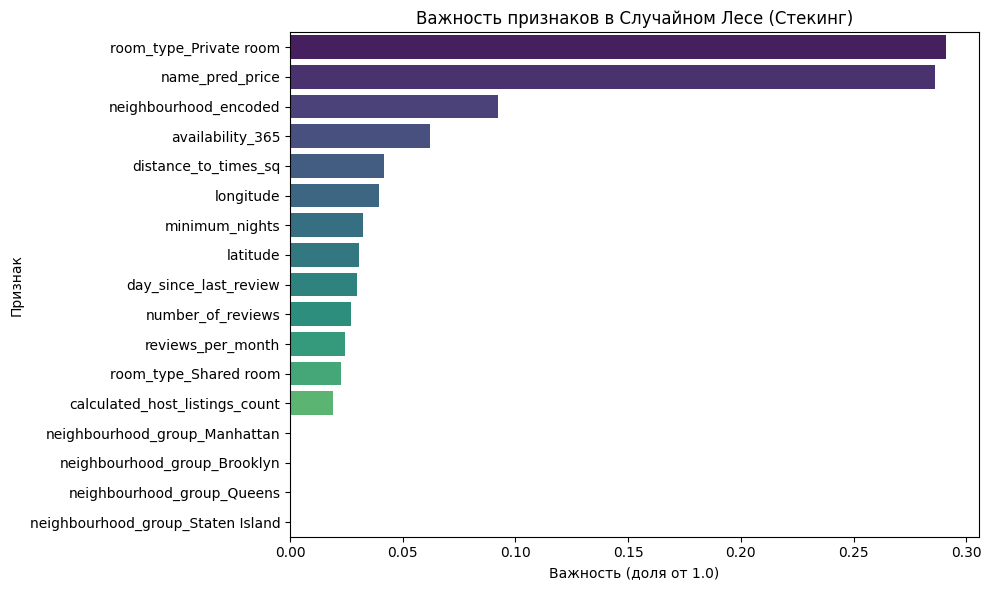

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = model.best_estimator_.feature_importances_
feature_names = X_train.columns

# Создаем удобную табличку
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Сортируем по убыванию важности
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Выводим в виде текста
print(feature_importance_df)

# Рисуем красивый график
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Важность признаков в Случайном Лесе (Стекинг)')
plt.xlabel('Важность (доля от 1.0)')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

**Вопросы для анализа:**
* **Сравнение скорости:** сравните, какая модель обучалась быстрее.
Если сравнивать между деревом и лесом, обучалось быстрее дерево, так как лес обучает несколько деревьев. И разумеется, что сокращение признаков (с 1685 до 17) значительно ускорило обучение (почти в 8-9 раз).
* **Можно ли добиться одинаковой или близкой к одинаковой скорости?**
Можно уменьшить, если строить деревья параллельно (указывается в параметре n_jobs). Если имеется столько же ядер в процессоре, сколько деревьев для леса надо обучить, то получится скорость приблизительно равное скорости обучения дерева.
* **Сравнение качества:** сравните результаты одного дерева и случайного леса. 
Как мы можем видеть, дерево больше переобучается, чем случайный лес. И метрики на тесте в обоих случаях повысились. Все из-за уменьшения разброса при увеличении количества деревьев.

**Ответьте на следующие вопросы: (если еще не отвечали в части про лин. рег)**
1. **Какие метрики вы использовали для сравнения моделей?** (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен $R^2$?).
Было отвечено в прошлом дз. Повторюсь кратко. В основном я опиралась на R^2. Это как бы отнормированный MSE который позволяет объективно оценить, насколько хорошо предсказано. Ещё опиралась на MAE из-за наличия выбросов (чтобы оценить насколько эффективно предсказывает в основной части)
2. **На какой части выборки вы считали метрики?** 
Считаются метрики на тестовой части для окончательной оценки. Если речь идет о подборе параметров, то считаем на валидационной
3. **Какая модель по итогу справилась лучше?**
Лучше всего справился случайный лес. А самый лучший подход оказался именно стекинг.
4. **Насколько хорошие получились результаты?** 
Результаты получились достаточно хорошими. Модель ближе к идеальной, чем к обычной константной (судя по метрике $R^2$)